#  Análisis de la Producción y Consumo de Petróleo a Nivel Global


## Integrantes del grupo 29:

* Sergio Nicolas Suarez
* Marcelo Enrique Delgado
* Pedro Roberti
* Ezequias Bonvissuto

Dataset: Our World in Data - Energy Dataset

## Entrega 1 - Ciencia de Datos  

##  A. Comprensión del negocio (Business Understanding - CRISP-DM)

### Contexto del problema

El presente análisis se enmarca en el dominio de la energía y la economía global, utilizando un dataset que contiene información sobre producción y consumo de petróleo, energía total y emisiones de CO₂ a nivel mundial.

Este tema es altamente relevante debido a:
- El papel central del petróleo en la economía mundial
- Su impacto en el desarrollo industrial y energético
- Su relación directa con el cambio climático a través de las emisiones de CO₂

Los principales actores que podrían beneficiarse de este análisis son:
- Gobiernos y organismos internacionales
- Empresas del sector energético
- Investigadores en sostenibilidad y medio ambiente
- Analistas económicos

### Formulación del problema

El problema que se busca abordar es comprender cómo evoluciona la producción y el consumo de petróleo a nivel global y analizar su relación con otras variables relevantes como el consumo energético total y las emisiones de CO₂.

Se pretende identificar patrones, tendencias y posibles relaciones entre estas variables que permitan una mejor comprensión del comportamiento energético global.

### Objetivos del análisis

Los objetivos del trabajo son:

- Analizar la evolución temporal de la producción y consumo de petróleo
- Identificar los países con mayor producción y consumo energético
- Evaluar la relación entre el consumo energético y las emisiones de CO₂
- Detectar patrones relevantes en el uso de recursos energéticos

Estos objetivos están orientados a generar información útil para la toma de decisiones en el ámbito energético y ambiental.

###  Preguntas analíticas

Las preguntas que guiarán el análisis son:

1. ¿Qué países presentan mayor producción de petróleo en los últimos años?
2. ¿Cómo evolucionó el consumo de petróleo a nivel global a lo largo del tiempo?
3. ¿Existe una relación entre el consumo energético total y las emisiones de CO₂?
4. ¿Se observan cambios significativos en los datos en eventos recientes como la pandemia de COVID-19 y la invasión de Rusia a Ucrania en 2024?

##  B. Comprensión de los datos (Data Understanding - CRISP-DM)

###  Fuente de datos

El dataset utilizado proviene de Our World in Data, una plataforma reconocida por recopilar y publicar datos abiertos sobre diversos temas globales.

- Fuente: Our World in Data
- URL: https://github.com/owid/energy-data
- Formato: CSV
- Acceso: público y gratuito

Los datos son recopilados a partir de múltiples fuentes oficiales y están disponibles para uso académico y de investigación.

### Carga de datos

In [ ]:
import pandas as pd

# Cargar dataset
url = "https://github.com/owid/energy-data/raw/master/owid-energy-data.csv"
df = pd.read_csv(url)


### Estructura del df

In [ ]:
# Cantidad de filas y columnas
df.shape

(23377, 130)

In [ ]:
# Tipos de datos
df.dtypes

,0
country,object
year,int64
iso_code,object
population,float64
gdp,float64
...,...
wind_elec_per_capita,float64
wind_electricity,float64
wind_energy_per_capita,float64
wind_share_elec,float64


In [ ]:
# Columnas
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=130)

### Primer vistazo

In [ ]:
# Primeras observaciones
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [ ]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.2+ MB


### Calidad de los datos

In [ ]:
# Porcentaje de nulos por columna
(df.isnull().sum() / len(df)) * 100

,0
country,0.000000
year,0.000000
iso_code,26.145357
population,19.176969
gdp,49.608590
...,...
wind_elec_per_capita,64.045857
wind_electricity,59.331822
wind_energy_per_capita,77.991188
wind_share_elec,67.228472


In [ ]:
# Ver filas con muchos datos faltantes
df.isnull().sum().sort_values(ascending=False).head(10)

,0
biofuel_cons_change_pct,21307
solar_cons_change_pct,20862
nuclear_cons_change_pct,20798
wind_cons_change_pct,20579
other_renewables_cons_change_pct,19389
electricity_share_energy,19274
low_carbon_energy_per_capita,18232
oil_energy_per_capita,18232
coal_cons_per_capita,18232
fossil_energy_per_capita,18232


###  Análisis preliminar de calidad de datos

A partir del análisis exploratorio se observa:

- Presencia de valores faltantes en varias variables, especialmente en indicadores energéticos específicos
- Diferentes tipos de variables (numéricas y categóricas)
- Posibles inconsistencias en la cobertura de datos según país y año

Se identifican variables que requerirán tratamiento en etapas posteriores, como:
- Manejo de valores nulos
- Selección de variables relevantes
- Filtrado de países o períodos de interés

##  C. Justificación de la elección del dataset

El dataset seleccionado resulta adecuado para el desarrollo de un proyecto de Ciencia de Datos debido a:

- Contiene una gran cantidad de registros (datos históricos por país y año)
- Incluye múltiples variables numéricas y categóricas
- Presenta características de datos reales, como valores faltantes e inconsistencias
- Permite abordar problemáticas relevantes en el ámbito energético y ambiental

Además, el dataset se vincula directamente con las preguntas analíticas planteadas, ya que incluye variables clave como producción de petróleo, consumo energético y emisiones de CO₂, lo que posibilita explorar relaciones entre ellas y analizar su evolución en el tiempo.

# Entrega 2: Análisis exploratorio y visualización

En esta segunda entrega se amplía el notebook inicial incorporando un análisis exploratorio de datos sobre el dataset de energía de Our World in Data.

El análisis se centra en variables vinculadas al petróleo, junto con variables complementarias como país, año, población, PBI y emisiones de gases de efecto invernadero.

# A. Preparación de los datos

Antes de comenzar el análisis exploratorio, se realizó una etapa de preparación y limpieza de datos con el objetivo de trabajar únicamente con las variables relevantes para el análisis.


### Limpieza de datos.
- El dataset no solo tiene datos de paises, sino que tambien agrupa regiones y continentes. Filtrando con la columna 'iso_code', nos permite quedarnos solo con los datos de paises, evitando duplicar sumas y conteos.
La ausencia de datos en la población nos impide hacer calculos matematicos.
Usamos 0 (cero) para mantener el tipo de dato y usamos 'int', ya que la poblacion es una variable discreta.

In [ ]:
#Preparación de los datos. (Aplicar tecnicas de data wrangling)
df_countries = df[df['iso_code'].notna()].copy()
# Dado que population tiene que ver con personas lo cambiamos a entero.
df_countries['population'] = df_countries['population'].fillna(0)
df_countries['population'] = df_countries['population'].astype(int)


## Selección de variables

Se seleccionaron únicamente las variables relacionadas con petróleo y variables complementarias relevantes para el análisis, como población, PBI y emisiones de gases de efecto invernadero.

Esto permite reducir la complejidad del dataset original y enfocarse específicamente en el problema planteado.

In [ ]:
# Columnas seleccionadas para el análisis

columns = [
    "country",
    "year",
    "iso_code",
    "population",
    "gdp",
    "greenhouse_gas_emissions",
    "oil_production",
    "oil_consumption",
    "oil_share_energy",
    "oil_electricity"
]

df_countries = df_countries[columns]

df_countries.tail()

,country,year,iso_code,population,gdp,greenhouse_gas_emissions,oil_production,oil_consumption,oil_share_energy,oil_electricity
23372,Zimbabwe,2020,ZWE,15526887,2.317871e+10,2.49,NaN,NaN,NaN,0.04
23373,Zimbabwe,2021,ZWE,15797220,2.514009e+10,2.31,NaN,NaN,NaN,0.00
23374,Zimbabwe,2022,ZWE,16069061,2.590159e+10,2.66,NaN,NaN,NaN,0.00
23375,Zimbabwe,2023,ZWE,16340829,NaN,3.92,NaN,NaN,NaN,0.00
23376,Zimbabwe,2024,ZWE,16634366,NaN,3.94,NaN,NaN,NaN,0.00


## B. Análisis descriptivo

En esta sección se analizan las variables principales mediante medidas de tendencia central, dispersión, rankings y tablas de frecuencia. El objetivo es comprender el comportamiento general de la producción y el consumo de petróleo.

### Producción acumulada histórica

In [ ]:
df_oil = df_countries[['country','year','oil_production','oil_consumption']]
# top productores de petroleo historico
df_top_prod = df_countries.groupby('country')['oil_production'].sum().sort_values(ascending=False).reset_index()
df_top_prod.columns = ['Pais','Produccion acumulada']
print(df_top_prod.head(10))

            Pais  Produccion acumulada
0  United States            447230.039
1   Saudi Arabia            295174.580
2         Russia            219678.853
3           Iran            137897.042
4      Venezuela            124371.497
5          China             96955.801
6         Canada             95907.816
7         Kuwait             90055.243
8         Mexico             87743.623
9           Iraq             85479.142


### Producción acumulada en los últimos 25 años

Además del análisis histórico completo, se decidió observar los últimos 25 años para tener una visión más reciente del comportamiento de los países productores.

In [ ]:
# Produccion acumulada ultimos 25 años
last_year = df_countries['year'].max()
years = 25
start_year = last_year - (years -1)
df_last_25y = df_countries[df_countries['year']>=start_year].copy()
df_top_prod_25y = df_last_25y.groupby('country')['oil_production'].sum().sort_values(ascending=False).reset_index()
df_top_prod_25y.columns=['Pais','Produccion']
print(df_top_prod_25y.head(10))


                   Pais  Produccion
0          Saudi Arabia  143819.527
1                Russia  141759.333
2         United States  138689.550
3                Canada   55503.503
4                  Iran   55118.654
5                 China   54073.057
6                  Iraq   44126.155
7  United Arab Emirates   43191.462
8                Mexico   38765.783
9                Kuwait   37549.216


En los últimos 25 años, Arabia Saudita, Rusia y Estados Unidos lideran la producción acumulada de petróleo. Este resultado permite responder la primera pregunta analítica planteada en la Entrega 1.

### Medidas descriptivas de producción

Se calcularon medidas de tendencia central para la producción de petróleo considerando únicamente países productores, es decir, aquellos con producción mayor a cero.

In [ ]:
#Medidas de tendencia y dispercion produccion
df_prod = df_last_25y[df_last_25y['oil_production']> 0].copy()
df_no_prod = df_last_25y['country'].nunique() - df_prod['country'].nunique()
print('La cantidad de no productores son:',df_no_prod)
print('Los paises productores son:',df_prod['country'].nunique())
print('El promedio es de:',df_prod['oil_production'].mean())
print('La mediana:',df_prod['oil_production'].median())
print('La moda:',df_prod['oil_production'].mode().values)

La cantidad de no productores son: 119
Los paises productores son: 101
El promedio es de: 587.9656054386865
La mediana: 71.839
La moda: [0.63]


La diferencia entre el promedio y la mediana indica una distribución asimétrica. Esto significa que pocos países concentran niveles muy altos de producción, elevando el promedio general.

### Consumo acumulado de petróleo

Se analiza el consumo acumulado de petróleo por país para identificar cuáles son los principales consumidores a nivel global.

In [ ]:
# Consumo acumulado ultimos 25 años
df_top_consum = df_oil.groupby('country')['oil_consumption'].sum().sort_values(ascending=False).reset_index()
df_top_consum.columns=['Pais','Total Consumo']
print(df_top_consum.head(10))

             Pais  Total Consumo
0   United States     571150.007
1           China     180347.819
2           Japan     158581.238
3         Germany      90014.187
4          Russia      78884.044
5           India      69387.870
6          Canada      64103.744
7          France      63450.445
8           Italy      61092.135
9  United Kingdom      58129.545


Estados Unidos aparece como el principal consumidor acumulado de petróleo, seguido por China, Japón e India. Esto refleja el peso de las grandes economías en la demanda energética mundial.

### Medidas de dispersión

Se calcularon la desviación estándar y el coeficiente de variación para producción y consumo de petróleo. Estas medidas permiten evaluar qué tan dispersos están los datos respecto del promedio.

In [ ]:
# Medida de tendencia y dispercion consumo
df_consum = df_oil[df_oil['year']>=start_year].copy()
df_consum_25y = df_consum.groupby('country')['oil_consumption'].sum().sort_values(ascending=False).reset_index()
df_consum_25y.columns=['Pais','Consumo']
print(df_consum_25y.head(10))
print("El promedio de consumo es de: ",df_consum['oil_consumption'].mean())
print('La mediana se encuentra en:', df_consum['oil_consumption'].median())
print('La moda:',df_consum['oil_consumption'].mode())

            Pais     Consumo
0  United States  244248.353
1          China  140582.438
2          Japan   59675.227
3          India   50346.735
4         Russia   41672.996
5   Saudi Arabia   38867.425
6    South Korea   32691.127
7        Germany   32443.868
8         Brazil   31031.206
9         Canada   29611.093
El promedio de consumo es de:  595.7186993670887
La mediana se encuentra en: 173.1015
La moda: 0     28.556
1     37.400
2     45.713
3     48.970
4    108.044
Name: oil_consumption, dtype: float64


In [ ]:
# Medidas de dispersion
std_prod = df_last_25y['oil_production'].std()
cv_prod = (std_prod / df_last_25y['oil_production'].mean()*100)

std_cons = df_consum['oil_consumption'].std()
cv_cons = (std_cons / df_consum['oil_consumption'].mean()*100)

print(f'Producción: desviacion estandar: {std_prod:.2f}, coeficiente de variacion: {cv_prod:.2f}.')
print(f'Consumo: desviacion estandar: {std_cons:.2f}, coeficiente de variacion: {cv_cons:.2f}.')

Producción: desviacion estandar: 927.37, coeficiente de variacion: 310.60.
Consumo: desviacion estandar: 1366.39, coeficiente de variacion: 229.37.


Los coeficientes de variación elevados muestran que existe una alta heterogeneidad entre países. Esto es esperable, ya que algunos países poseen una participación muy alta en la producción o consumo de petróleo, mientras que otros tienen valores bajos o nulos.

### Categorización de países según nivel de producción

Para facilitar la interpretación, se creó una variable categórica llamada `nivel_produccion`, que clasifica los registros en cuatro grupos: Bajo, Medio-Bajo, Medio-Alto y Alto.

In [ ]:
category = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
df_prod['nivel_produccion'] = pd.qcut(df_prod['oil_production'], q=4, labels=category)

frec_abs = df_prod['nivel_produccion'].value_counts()
frec_rel = df_prod['nivel_produccion'].value_counts(normalize=True) * 100
tabla_cat = pd.DataFrame({
    'Frecuencia Absoluta': frec_abs,
    'Proporción (%)': frec_rel
})
print(tabla_cat)

                  Frecuencia Absoluta  Proporción (%)
nivel_produccion                                     
Bajo                              488       25.038481
Medio-Bajo                        487       24.987173
Medio-Alto                        487       24.987173
Alto                              487       24.987173


La tabla de frecuencias muestra una distribución equilibrada entre las categorías, ya que fueron construidas mediante cuartiles. Esta transformación permite analizar la producción desde una perspectiva categórica.

### Identificación de valores atípicos

Se aplicó el método del rango intercuartílico (IQR) para detectar valores atípicos en la producción de petróleo.

In [ ]:
# Cálculo de Outliers para Producción
Q1 = df_prod['oil_production'].quantile(0.25)
Q3 = df_prod['oil_production'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = df_prod[df_prod['oil_production'] > limite_superior]
n_outliers = outliers['country'].nunique()

print(f"Cantidad de países atípicos: {n_outliers}")
print("Principales atípicos:", outliers['country'].unique())

Cantidad de países atípicos: 15
Principales atípicos: ['Brazil' 'Canada' 'China' 'Iran' 'Iraq' 'Kuwait' 'Mexico' 'Nigeria'
 'Norway' 'Russia' 'Saudi Arabia' 'United Arab Emirates' 'United Kingdom'
 'United States' 'Venezuela']


Los valores atípicos detectados corresponden principalmente a grandes productores mundiales de petróleo. En este caso, no se consideran errores, sino observaciones relevantes para el análisis.

Por lo tanto, no se eliminan del dataset, ya que representan países estratégicos dentro del mercado energético global.

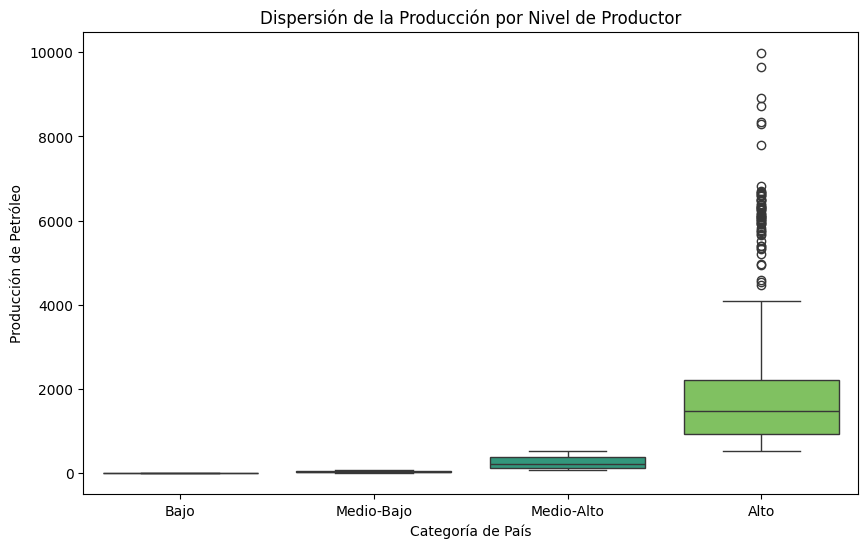

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='nivel_produccion',
    y='oil_production',
    data=df_prod,
    hue='nivel_produccion',
    palette='viridis',
    legend=False
)

plt.title('Dispersión de la Producción por Nivel de Productor')
plt.ylabel('Producción de Petróleo')
plt.xlabel('Categoría de País')
plt.show()

### Visualización 1: Dispersión de producción por nivel de productor

Esta visualización permite observar cómo se distribuye la producción de petróleo dentro de las categorías construidas a partir de cuartiles.

Como podemos observar, los valores atipicos en la producción se enfocan en los paises de alta producción.
En este analisis en particular, no debemos descartarlos sino hacer foco en los mismos ya que se trata de paises potencia en el sector, que no solo lo usan como consumo interno sino tambien son exportadores de crudo.
Tales ejemplos pueden ser Rusia y Arabia Saudita que solo consumen una sexta parte de lo que producen.


## C. Análisis de relaciones entre variables

En esta sección se exploran relaciones entre variables relevantes del dataset, principalmente entre producción y consumo de petróleo.

### Relación entre producción y consumo en los principales países productores

Se seleccionaron los 10 principales productores del último año disponible y se analizó la evolución de su producción y consumo durante los últimos 20 años.

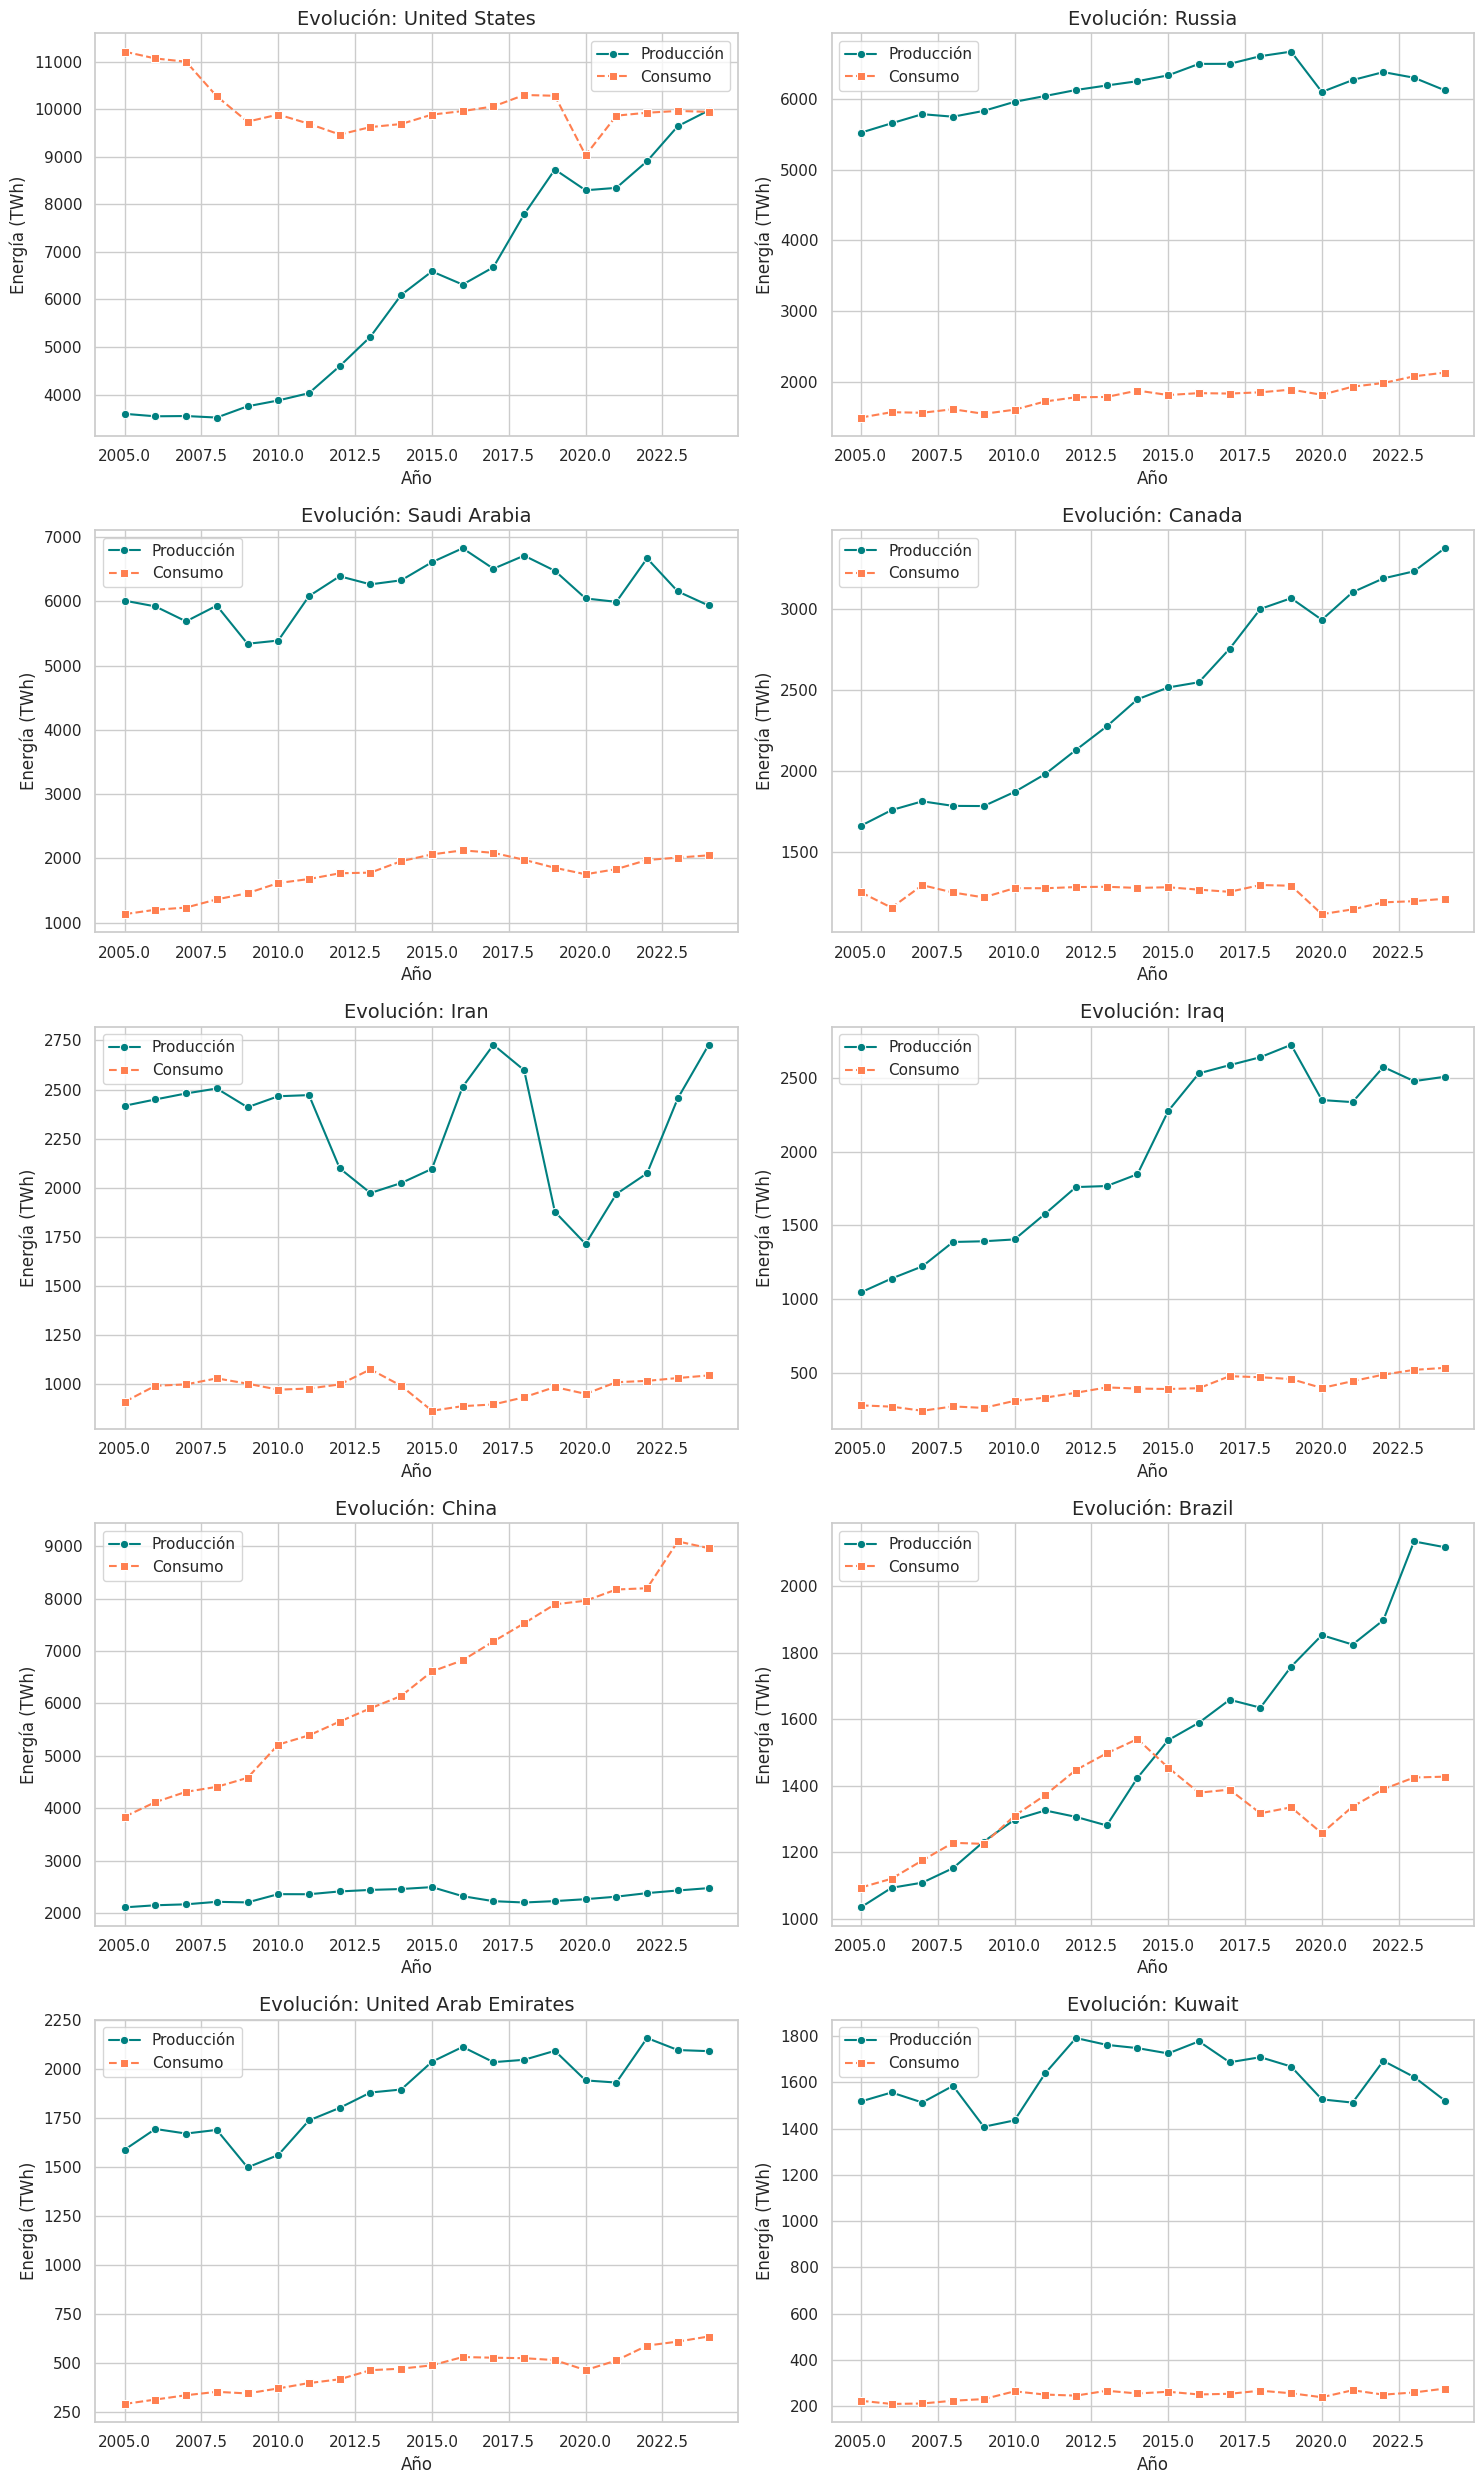

In [ ]:
df_oil = df_countries[["country", "year", "oil_production", "oil_consumption"]].dropna()

# 3. Identificar el Top 10 de productores del último año
latest_year = df_oil["year"].max()
top10_nombres = df_oil[df_oil["year"] == latest_year].nlargest(10, "oil_production")["country"].tolist()

# 4. Filtrar los últimos 20 años para esos países
df_top20 = df_oil[(df_oil["country"].isin(top10_nombres)) & (df_oil["year"] >= (latest_year - 19))]

# 5. Configuración del Plot (Grilla de 5x2)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25))
axes = axes.flatten()

for i, country in enumerate(top10_nombres):
    # Filtramos y ordenamos por año para que la línea no se cruce
    data_country = df_top20[df_top20["country"] == country].sort_values("year")

    # Producción (Línea sólida) y Consumo (Línea punteada)
    sns.lineplot(data=data_country, x='year', y='oil_production', ax=axes[i],
                 label='Producción', marker='o', color='teal')
    sns.lineplot(data=data_country, x='year', y='oil_consumption', ax=axes[i],
                 label='Consumo', marker='s', color='coral', linestyle='--')

    axes[i].set_title(f'Evolución: {country}', fontsize=14)
    axes[i].set_xlabel('Año', fontsize=12)
    axes[i].set_ylabel('Energía (TWh)', fontsize=12)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Visualización 2: Evolución de producción y consumo en principales países productores

Esta visualización compara la producción y el consumo de petróleo en los principales países productores durante los últimos 20 años.

En algunos casos, como Arabia Saudita o Rusia, la producción supera ampliamente al consumo interno, lo que indica un perfil exportador. En otros casos, como Estados Unidos, la diferencia entre producción y consumo es menor, lo que refleja una demanda interna muy elevada.

# ¿Cómo evolucionó el consumo de petróleo a nivel global a lo largo del tiempo?

- En el siguiente apartado buscamos responder la pregunta 2 de la primera etapa.

In [ ]:
pd_hist_cons = df_countries.groupby('year')['oil_consumption'].sum().reset_index()
pd_hist_cons = pd_hist_cons[pd_hist_cons['oil_consumption']>0]
pd_hist_cons.columns = ['Año','Consumo']

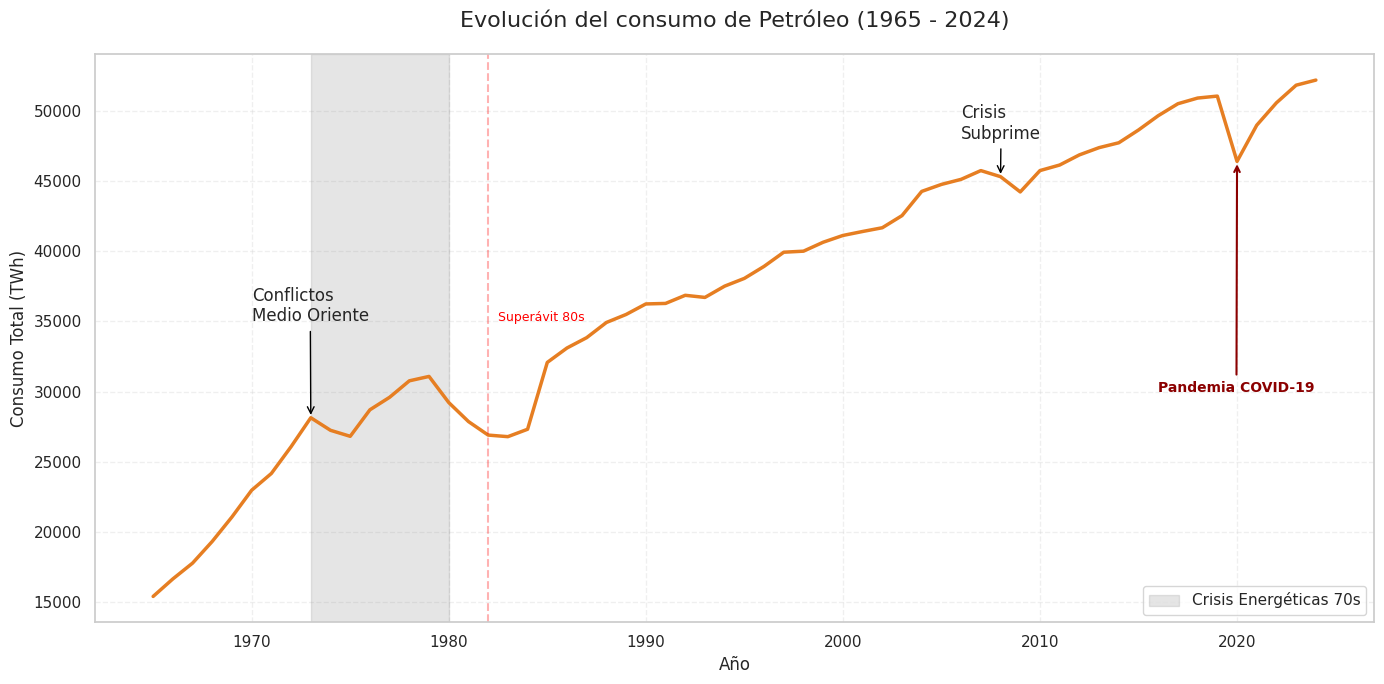

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=pd_hist_cons, x='Año', y='Consumo', color='#e67e22', linewidth=2.5)

plt.axvspan(1973, 1980, color='gray', alpha=0.2, label='Crisis Energéticas 70s')
plt.annotate('Conflictos\nMedio Oriente', xy=(1973, pd_hist_cons[pd_hist_cons['Año']==1973]['Consumo'].values[0]),
             xytext=(1970, 35000), arrowprops=dict(arrowstyle='->', color='black'))

# 2. Crisis de los 80
plt.axvline(x=1982, color='red', linestyle='--', alpha=0.3)
plt.text(1982.5, 35000, 'Superávit 80s', fontsize=9, color='red')

# 3. Crisis Financiera 2008
plt.annotate('Crisis\nSubprime', xy=(2008, pd_hist_cons[pd_hist_cons['Año']==2008]['Consumo'].values[0]),
             xytext=(2006, 48000), arrowprops=dict(arrowstyle='->', color='black'))

# 4. Pandemia COVID-19
plt.annotate('Pandemia COVID-19', xy=(2020, pd_hist_cons[pd_hist_cons['Año']==2020]['Consumo'].values[0]),
             xytext=(2016, 30000), arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
             fontsize=10, weight='bold', color='darkred')

# --- Estética del gráfico ---
plt.title('Evolución del consumo de Petróleo (1965 - 2024)', fontsize=16, pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Consumo Total (TWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Visualización 3: Evolución del consumo global de petróleo

Esta visualización permite analizar cómo cambió el consumo global de petróleo entre 1965 y 2024, incorporando referencias a eventos históricos relevantes.

Se observa una tendencia general creciente en el consumo global de petróleo, aunque con caídas o desaceleraciones en períodos asociados a crisis energéticas, económicas o sanitarias.

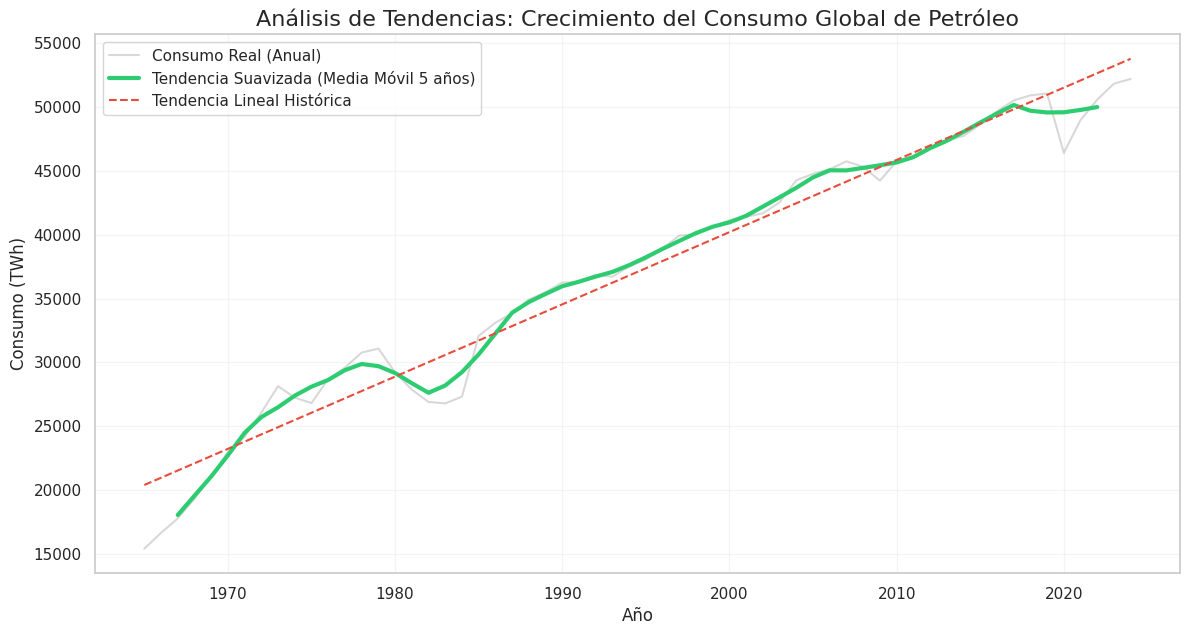

In [ ]:
from sklearn.linear_model import LinearRegression
pd_hist_cons['Media_Movil'] = pd_hist_cons['Consumo'].rolling(window=5, center=True).mean()

X = pd_hist_cons['Año'].values.reshape(-1, 1)
y = pd_hist_cons['Consumo'].values
modelo = LinearRegression().fit(X, y)
tendencia_lineal = modelo.predict(X)

plt.figure(figsize=(14, 7))

sns.lineplot(data=pd_hist_cons, x='Año', y='Consumo', color='gray', alpha=0.3, label='Consumo Real (Anual)')

sns.lineplot(data=pd_hist_cons, x='Año', y='Media_Movil', color='#2ecc71', linewidth=3, label='Tendencia Suavizada (Media Móvil 5 años)')

plt.plot(pd_hist_cons['Año'], tendencia_lineal, color='#e74c3c', linestyle='--', label='Tendencia Lineal Histórica')
plt.title('Análisis de Tendencias: Crecimiento del Consumo Global de Petróleo', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Consumo (TWh)')
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

### Visualización 4: Tendencia suavizada del consumo global

Para observar con mayor claridad la tendencia de largo plazo, se incorporó una media móvil de 5 años y una tendencia lineal histórica.

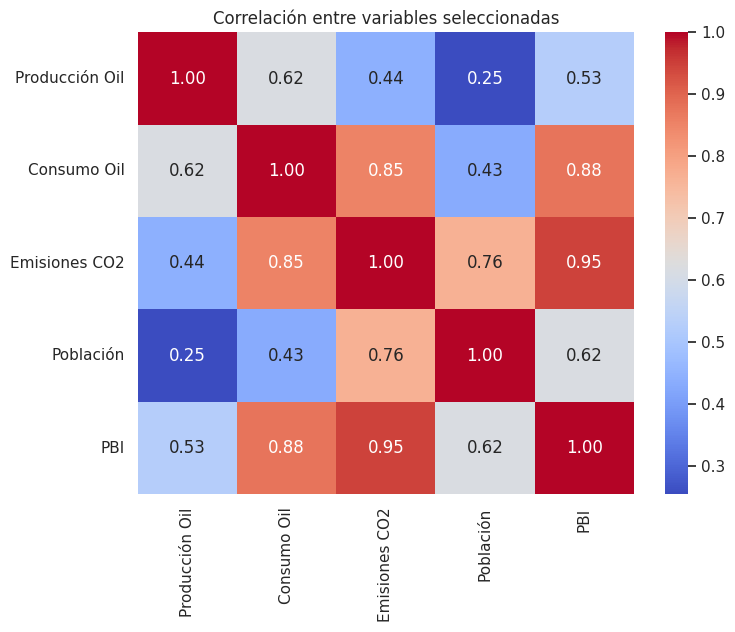

In [ ]:
corr_cols = [
    'oil_production',
    'oil_consumption',
    'greenhouse_gas_emissions',
    'population',
    'gdp'
]

corr = df_countries[corr_cols].corr()

corr.rename(
    index={
        'oil_production': 'Producción Oil',
        'oil_consumption': 'Consumo Oil',
        'greenhouse_gas_emissions': 'Emisiones CO2',
        'population': 'Población',
        'gdp': 'PBI'
    },
    columns={
        'oil_production': 'Producción Oil',
        'oil_consumption': 'Consumo Oil',
        'greenhouse_gas_emissions': 'Emisiones CO2',
        'population': 'Población',
        'gdp': 'PBI'
    },
    inplace=True
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Correlación entre variables seleccionadas')

plt.show()

### Visualización 5: Correlación entre variables seleccionadas

Se analiza la relación entre variables numéricas relevantes como producción de petróleo, consumo de petróleo, emisiones de gases de efecto invernadero, población y PBI.

La matriz de correlación permite identificar relaciones lineales entre las variables seleccionadas.

Una correlación positiva entre consumo de petróleo y emisiones de gases de efecto invernadero indicaría que los países con mayor consumo tienden también a presentar mayores emisiones. También puede observarse la relación entre PBI, población y consumo energético.

## E. Síntesis del análisis exploratorio

A partir del análisis exploratorio realizado se identificaron varios hallazgos relevantes.

En primer lugar, la producción de petróleo se encuentra concentrada en un grupo reducido de países, entre los que se destacan Arabia Saudita, Rusia y Estados Unidos en los últimos 25 años.

En segundo lugar, el consumo global de petróleo muestra una tendencia creciente a lo largo del tiempo, aunque con caídas asociadas a eventos históricos como crisis energéticas, crisis económicas y la pandemia de COVID-19.

También se observaron valores atípicos en la producción de petróleo. Sin embargo, estos no fueron eliminados, ya que representan países con alta relevancia en el mercado energético y no errores de carga.

Con el EDA ya se pueden responder parcialmente algunas preguntas de la Entrega 1, como qué países producen más petróleo y cómo evolucionó el consumo global a lo largo del tiempo.

Sin embargo, preguntas relacionadas con la predicción futura del consumo o la explicación más profunda de la relación entre petróleo, PBI y emisiones podrían requerir un abordaje más avanzado, como modelos estadísticos o predictivos.

Finalmente, existen indicios de que un modelo predictivo podría ser útil, especialmente para estimar tendencias futuras de consumo o producción de petróleo a partir de variables como año, población, PBI y emisiones.

# Entrega 3: Evaluación de la pertinencia del modelado

En esta etapa final del proyecto se evalúa si el dataset analizado resulta adecuado para la aplicación de técnicas de aprendizaje automático.

A partir de los resultados obtenidos en el análisis exploratorio de datos (EDA), se analizará la viabilidad del modelado, el tipo de problema que podría abordarse y las limitaciones presentes en el dataset.

##  Pertinencia del modelado

A partir del análisis exploratorio realizado en las etapas anteriores, se considera que el dataset es apto para la aplicación de modelos de aprendizaje automático.

El análisis mostró:
- tendencias temporales claras en el consumo y producción de petróleo
- relaciones entre variables económicas, energéticas y ambientales
- suficiente cantidad de registros históricos
- variables numéricas relevantes para realizar predicciones

Además, se identificaron correlaciones entre variables como consumo de petróleo, emisiones de gases de efecto invernadero y PBI, lo que sugiere que un modelo podría aportar valor para estimar comportamientos futuros.

##  Tipo de tarea de aprendizaje automático

El problema identificado corresponde a una tarea de aprendizaje supervisado de tipo regresión.

Esto se debe a que el objetivo sería predecir una variable numérica continua, como el consumo o la producción de petróleo, a partir de otras variables disponibles en el dataset.

La elección de regresión se fundamenta en:
- la naturaleza numérica de las variables
- las relaciones observadas en el EDA
- la existencia de tendencias históricas temporales

##  Variable objetivo

La variable objetivo seleccionada sería `oil_consumption`, ya que representa el consumo de petróleo de cada país en un año determinado.

Esta variable resulta adecuada porque:
- presenta una tendencia histórica observable
- posee relación con variables económicas y energéticas
- tiene relevancia desde el punto de vista energético y ambiental

Como variables predictoras podrían utilizarse:
- año
- población
- PBI
- emisiones de gases de efecto invernadero
- producción de petróleo

## Implementación exploratoria de un modelo de regresión lineal

Con el objetivo de evaluar preliminarmente la viabilidad del modelado, se implementó un modelo simple de regresión lineal.

El objetivo del modelo es predecir el consumo de petróleo (`oil_consumption`) utilizando variables económicas, demográficas y energéticas disponibles en el dataset.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Selección de variables
model_df = df_countries[
    [
        'year',
        'population',
        'gdp',
        'greenhouse_gas_emissions',
        'oil_production',
        'oil_consumption'
    ]
].dropna()

# Variables predictoras
X = model_df[
    [
        'year',
        'population',
        'gdp',
        'greenhouse_gas_emissions',
        'oil_production'
    ]
]

# Variable objetivo
y = model_df['oil_consumption']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Modelo
model = LinearRegression()

model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Métricas
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 171.489855048887
R2: 0.9185013206744792


### Interpretación de métricas

Para evaluar el comportamiento del modelo se utilizaron dos métricas principales:

- **MAE (Mean Absolute Error):** mide el error promedio entre los valores reales y las predicciones realizadas por el modelo.
- **R² (Coeficiente de determinación):** indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

Un valor de R² más cercano a 1 indica un mejor ajuste del modelo.

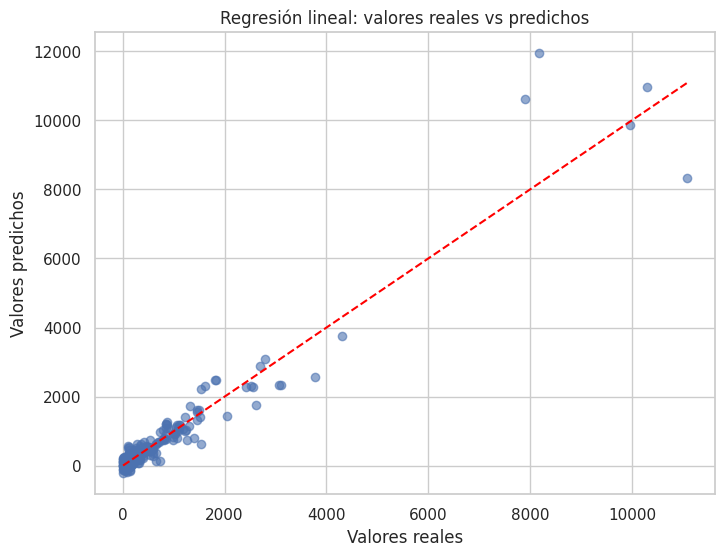

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")

plt.title("Regresión lineal: valores reales vs predichos")

plt.grid(True)

plt.show()

 ### Interpretación del gráfico
El gráfico compara los valores reales de consumo de petróleo con los valores predichos por el modelo de regresión lineal.

Se observa que existe una relación positiva entre ambas variables, lo que indica que el modelo logra capturar parcialmente el comportamiento del consumo de petróleo a partir de las variables seleccionadas.

Sin embargo, también se aprecia cierta dispersión, lo que sugiere que existen factores adicionales no incluidos en el modelo que afectan el consumo energético.

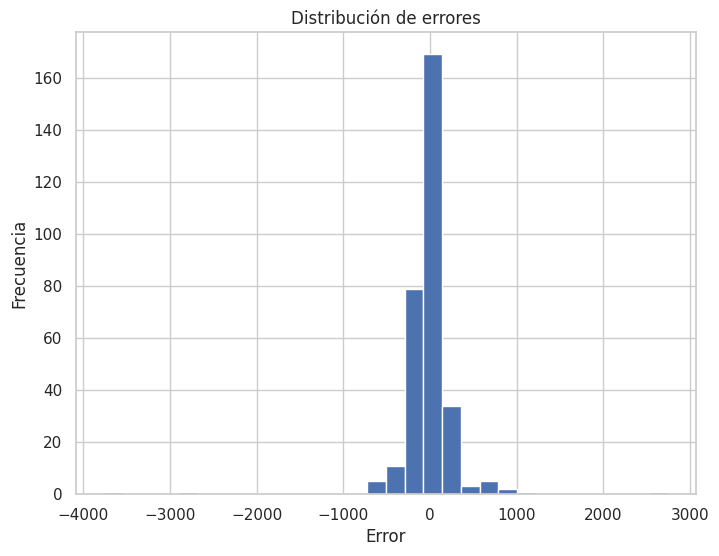

In [ ]:
errores = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(errores, bins=30)

plt.title("Distribución de errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación de errores
La distribución de errores permite observar cómo se comportan las diferencias entre los valores reales y las predicciones realizadas por el modelo.

La concentración de errores cerca de cero sugiere que el modelo logra aproximar razonablemente el comportamiento general de los datos.

##  Limitaciones y riesgos

A pesar de que el modelado resulta viable, se identifican algunas limitaciones importantes:

- presencia de valores faltantes en algunas variables
- diferencias significativas entre países
- existencia de valores atípicos
- posibles cambios estructurales en eventos históricos globales

Además, el consumo energético puede verse afectado por factores externos no incluidos en el dataset, como conflictos geopolíticos, políticas energéticas o cambios tecnológicos.

Antes de implementar un modelo más robusto sería recomendable:
- realizar ingeniería de variables
- evaluar transformaciones y normalización
- analizar modelos más complejos
- incorporar más variables explicativas

##  Conclusión

A partir del trabajo realizado se concluye que el dataset presenta condiciones adecuadas para la aplicación de modelos de aprendizaje automático.

El análisis exploratorio permitió identificar patrones, tendencias y relaciones entre variables que respaldan la posibilidad de construir modelos predictivos orientados al análisis energético.

Particularmente, se considera viable el desarrollo de modelos de regresión para estimar consumo o producción de petróleo utilizando variables económicas, demográficas y ambientales.

Sin embargo, también se identificaron limitaciones que deberían abordarse en futuras etapas para mejorar la calidad y robustez de los modelos.

# Uso de herramientas de IA

Durante el desarrollo del presente trabajo se utilizaron herramientas de inteligencia artificial generativa como apoyo para:

- asistencia en la redacción de textos descriptivos e interpretaciones
- sugerencias de visualizaciones y estructura del análisis exploratorio
- apoyo en la generación y corrección de fragmentos de código en Python
- orientación conceptual sobre técnicas de análisis y modelado

Las herramientas utilizadas incluyeron principalmente ChatGPT.

Todo el contenido generado con asistencia de IA fue revisado, adaptado y validado por los integrantes del grupo. Asimismo, cada integrante comprende el funcionamiento del código, las decisiones tomadas y las conclusiones obtenidas a lo largo del proyecto.